In [7]:
import sys
sys.path.insert(0, '..')
from typing import Callable

import altair as alt
import polars as pl

from IPython.display import display, HTML
from diaphanous.nibrs import configure, format_table, humanize_frame, load_all, Id
import diaphanous.bka as bka
from diaphanous.chart import plot_age_distribution

def html(markup: str) -> None:
    display(HTML(markup))

def hn(level: int) -> Callable[[str], None]:
    if not 1 <= level <= 6:
        raise ValueError(f"invalid heading level {level}")
    def h(title: str) -> None:
        html(f"<h{level}>{title}</h{level}>")
    return h

h1 = hn(1)
h2 = hn(2)
h3 = hn(3)

import rpy2
%load_ext rpy2.ipython
import diaphanous.arr as arr
#arr.enable_write_hook()
arr.install()
RLIB = arr.RLIB

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [8]:
h1("Overview")

configure()
us = load_all()
display(us.caseload_table())
display(us.severity_table())
display(us.completion_table())

de = bka.ingest()
# print(de.filter(pl.col("id").is_in(["143210", "143220", "143510", "143520"]).and_(pl.col("sex").eq("X"))).group_by("data_year").agg(pl.col("total").sum()))
# print(de.filter(pl.col("id").is_in(["143230", "143530"]).and_(pl.col("sex").eq("X"))).group_by("data_year").agg(pl.col("total").sum()))

offenders = us.offender_demographics().age_distribution()
suspects = bka.age_distribution(de)

fig = alt.vconcat(
    plot_age_distribution(offenders, "Offenders", "US"),
    plot_age_distribution(suspects, "Offenders", "Germany"),
).resolve_scale(x="shared")

fig.save("../figure/age-distributions.svg")
fig

GT(_tbl_data=shape: (3, 4)
┌───────────┬────────────┬─────────┬────────────┐
│ Variant   ┆ Count 2023 ┆ ∆% 2024 ┆ Count 2024 │
│ ---       ┆        --- ┆     --- ┆        --- │
│ str       ┆        u32 ┆     f64 ┆        u32 │
╞═══════════╪════════════╪═════════╪════════════╡
│ Offenders ┆     16,565 ┆     0.1 ┆     18,038 │
│ Incidents ┆     15,199 ┆     0.1 ┆     16,500 │
│ Arrestees ┆      2,703 ┆     0.2 ┆      3,280 │
└───────────┴────────────┴─────────┴────────────┘, _body=<great_tables._gt_data.Body object at 0x12e5d3350>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='Count 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='∆% 2024', type=<ColInfoTypeEnum.default: 1>, column_label='∆%', column_align='right', column_width=None), ColInfo(var='Count 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1317bd7b0>, _spanners=Spanners([SpannerInfo(spanner_id='2023', spanner_level=0, spanner_label='2023', spanner_units=None, spanner_pattern=None, vars=['Count 2023'], built=None), SpannerInfo(spanner_id='2024', spanner_level=0, spanner_label='2024', spanner_units=None, spanner_pattern=None, vars=['∆% 2024', 'Count 2024'], built=None)]), _heading=Heading(title='CSAM Caseload', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1317e7490>, _formats=[<great_tables._gt_data.FormatInfo object at 0x142459050>, <great_tables._gt_data.FormatInfo object at 0x12e7e7200>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x14241da90>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True,

GT(_tbl_data=shape: (3, 5)
┌─────────┬────────────┬──────────────┬────────────┬──────────────┐
│ Variant ┆ Count 2023 ┆ Percent 2023 ┆ Count 2024 ┆ Percent 2024 │
│ ---     ┆        --- ┆          --- ┆        --- ┆          --- │
│ str     ┆        u32 ┆          f64 ┆        u32 ┆          f64 │
╞═════════╪════════════╪══════════════╪════════════╪══════════════╡
│ Supply  ┆      1,190 ┆          0.1 ┆      1,260 ┆          0.1 │
│ Demand  ┆     14,009 ┆          0.9 ┆     15,240 ┆          0.9 │
│ 🖩 Total ┆     15,199 ┆          1.0 ┆     16,500 ┆          1.0 │
└─────────┴────────────┴──────────────┴────────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x14249ac10>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='Count 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='Percent 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Percent', column_align='right', column_width=None), ColInfo(var='Count 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='Percent 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Percent', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x131807650>, _spanners=Spanners([SpannerInfo(spanner_id='2023', spanner_level=0, spanner_label='2023', spanner_units=None, spanner_pattern=None, vars=['Count 2023', 'Percent 2023'], built=None), SpannerInfo(spanner_id='2024', spanner_level=0, spanner_label='2024', spanner_units=None, spanner_pattern=None, vars=['Count 2024', 'Percent 2024'], built=None)]), _heading=Heading(title='Offense Severity', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1317e75c0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x14249aeb0>, <great_tables._gt_data.FormatInfo object at 0x14249a7b0>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x142436340>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_s

GT(_tbl_data=shape: (2, 3)
┌───────────┬────────┬────────┐
│ Variant   ┆   2023 ┆   2024 │
│ ---       ┆    --- ┆    --- │
│ str       ┆    u32 ┆    u32 │
╞═══════════╪════════╪════════╡
│ Attempted ┆    557 ┆    607 │
│ Completed ┆ 14,642 ┆ 15,893 │
└───────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x12e0b3650>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='2023', type=<ColInfoTypeEnum.default: 1>, column_label='2023', column_align='right', column_width=None), ColInfo(var='2024', type=<ColInfoTypeEnum.default: 1>, column_label='2024', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x12e7e75c0>, _spanners=Spanners([]), _heading=Heading(title='Offense Completion', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x14244e450>, _formats=[<great_tables._gt_data.FormatInfo object at 0x12e72fdd0>, <great_tables._gt_data.FormatInfo object at 0x142460590>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x142430260>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo

alt.VConcatChart(...)

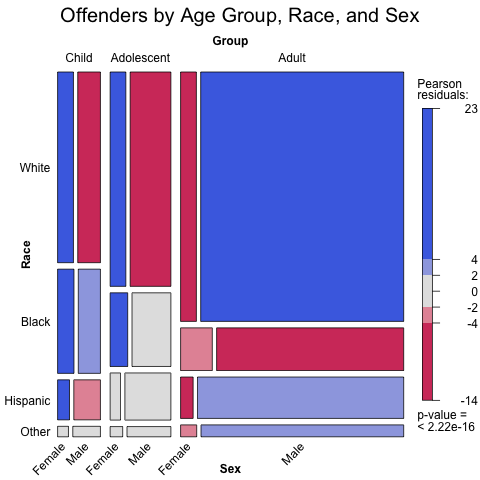

In [9]:
%%R -i RLIB

.libPaths(RLIB)
library(tidyverse)

nibrs <- read.csv("../data/nibrs/offenders.csv")
nibrs <- nibrs |>
  mutate(
    Group = factor(Group, levels = c("Child", "Adolescent", "Adult")),
    Sex = factor(Sex, levels = c("Female", "Male")),
    Race = factor(Race, levels = c("White", "Black", "Hispanic", "Other"))
  )

nibrs.24 <- nibrs |> filter(Year == 2024)
nibrs.24.contab <- xtabs(Count ~ Group + Race + Sex, data = nibrs.24)

library(vcdExtra)
vcd::mosaic(
  ~ Group + Race + Sex, data = nibrs.24.contab, direction = c("v", "h", "v"),
  shade = TRUE,
  main = "Offenders by Age Group, Race, and Sex",
  rot_labels = c(0, 0, 45, 0),
  offset_labels = c(0, 0, -0.5, -0.5),
  just_labels = c("center", "left", "right", "right"),
  offset_varnames = c(0.2, 0, 0.2, 0.2),
  margins = c(3, 0.3, 3, 4)
)

Rows: 12 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Group, Sex
dbl (2): Year, Count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


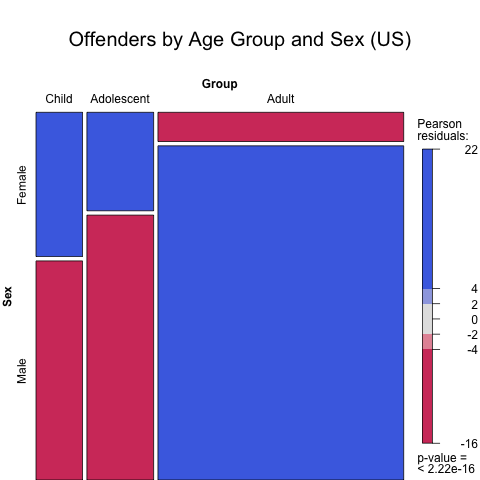

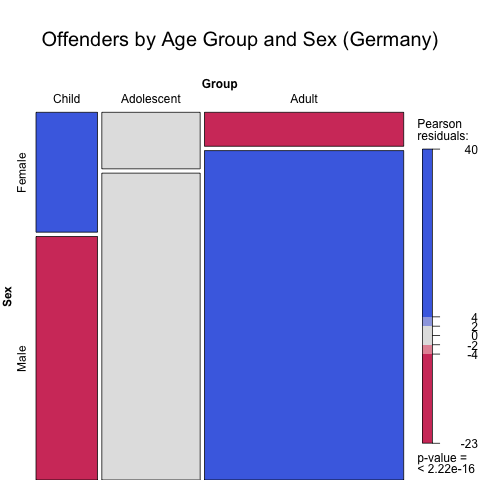

In [10]:
%%R -i RLIB

nibrs.24.age.sex <- xtabs(Count ~ Group + Sex, data = nibrs.24)

vcd::mosaic(
  ~ Group + Sex,
  data = nibrs.24.age.sex,
  direction = c("v", "h"),
  shade = TRUE,
  margins = c(2.5, 0.3, 0, 2.5),
  main = "Offenders by Age Group and Sex (US)",
)

bka.24 <- read_csv("../data/bka/suspects.csv") |>
  mutate(
    Group = factor(Group, levels = c("Child", "Adolescent", "Adult")),
    Sex = factor(Sex, levels = c("Female", "Male")),
  ) |>
  filter(Year == 2024)
bka.24.age.sex <- xtabs(Count ~ Group + Sex, data = bka.24)

vcd::mosaic(
  ~ Group + Sex,
  data = bka.24.age.sex,
  direction = c("v", "h"),
  shade = TRUE,
  margins = c(2.5, 0.3, 0, 2.5),
  main = "Offenders by Age Group and Sex (Germany)"
)

In [11]:
# h1("Attribute Impact on Offender Age Groups")

# for year, data in yearly.items():
#     h2(f"{year}")
#     arrestees = data.arrestee_demographics()
#     offenders = data.offender_demographics()

#     DISTRIBUTIONS = (
#         arrestees.age_distribution(grouped=False),
#         offenders.variant_distribution("Female"),
#         offenders.variant_distribution("Male"),
#         offenders.variant_distribution("Black"),
#         offenders.variant_distribution("White"),
#         offenders.location_distribution("In Cyberspace", Location.CYBERSPACE),
#         offenders.location_distribution(
#             "At School",
#             Location.SCHOOL_ELEMENTARY_SECONDARY,
#             Location.SCHOOL_COLLEGE,
#         ),
#         offenders.location_distribution("At Home", Location.RESIDENCE_HOME),
#         offenders.using_distribution(
#             "With Computer", Using.COMPUTER_EQUIPMENT_HANDHELD_DEVICES
#         ),
#         offenders.clearance_distribution("Juvenile", Clearance.JUVENILE),
#     )

#     display(offenders.chart_counts())

#     for label, overlay in DISTRIBUTIONS:
#         display(offenders.chart_counts(label, overlay))

In [12]:
# h1("Attribute / Offender Ratio")

# for year, data in yearly.items():
#     h2(f"{year}")
#     offenders = data.offender_demographics()

#     display(offenders.chart_ratios(*DISTRIBUTIONS[:5]))
#     display(offenders.chart_ratios(*DISTRIBUTIONS[5:]))

#     h3("Using Three-Year Rolling Average for Smoothing")

#     display(offenders.chart_ratios(*DISTRIBUTIONS[:5], smooth=True))
#     display(offenders.chart_ratios(*DISTRIBUTIONS[5:], smooth=True))